# Spike sorting - coding

In this chapter we will run spike sorting on a preprocessed recording, compare the
output of different sorters, and get familiar with the `Sorting` object that
sorter returns. Morever, we will create a `SortingAnalyzer` object and compute
additional extensions to get ready for curation.

We will use the same short example dataset as before: a 90 second slice of a
64-channel recording, downloaded from DANDI and saved locally in binary format.

Let's get started!

First of all, let's import some `spikeinterface` modules:

In [8]:
from pathlib import Path

import spikeinterface as si
import spikeinterface.preprocessing as spre
import spikeinterface.widgets as sw

import matplotlib.pyplot as plt

In [9]:
%matplotlib widget

In [10]:
si.set_global_job_kwargs(n_jobs=0.5, chunk_duration="1s", progress_bar=True)

## Data loading and preprocessing

Then, we reload the preprocessed data.
If they are not available, we load recording and quickly apply the preprocessing chain
(bandpass filter + common median reference) covered in the previous chapter.

BinaryFolderRecording: 61 channels - 20.0kHz - 1 segments - 1,800,000 samples 
                       90.00s (1.50 minutes) - int16 dtype - 209.43 MiB


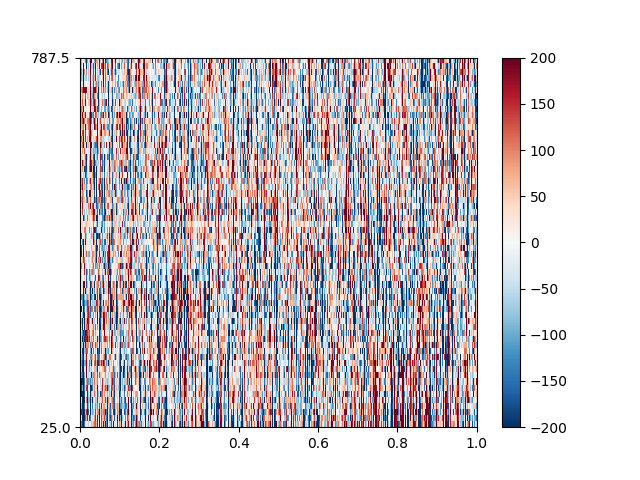

In [16]:
preprocessed_json = Path(r"C:\Users\Joe\work\git-repos\course_ephys_osss\book\data\preprocessed-dandiset-000939")
recording_preprocessed = si.load(preprocessed_json)
print(recording_preprocessed)

import spikeinterface.widgets as sw
sw.plot_traces(recording_preprocessed, mode="map")

In [6]:
if preprocessed_json.is_file():
    recording_preprocessed = si.load(preprocessed_json)
else:
    print("DONE")
    from course_ephys_osss.data.utils import download_and_slice_nwb_from_dandi

    dataset_folder = Path("data/nwb_recording")

    if not dataset_folder.exists():
        download_and_slice_nwb_from_dandi(
            s3_url="https://dandiarchive.s3.amazonaws.com/blobs/a8f/800/a8f8003e-4483-4b50-8a45-91ac5971f5d5",
            duration_s=90,
            local_folder=dataset_folder
        )
    recording = si.load(dataset_folder)
    recording_f = spre.bandpass_filter(recording, freq_min=300, freq_max=6000)
    recording_preprocessed = spre.common_reference(recording_f, operator="median")

DONE


In [7]:
print(recording_preprocessed)

CommonReferenceRecording: 64 channels - 20.0kHz - 1 segments - 1,800,000 samples 
                          90.00s (1.50 minutes) - int16 dtype - 219.73 MiB


## Check installation

We can now run spike sorting on the preprocessed recording. There are many
spike sorters available in SpikeInterface, and part of what makes the package
so useful is that it makes it easy to interchangeably run different sorters
using the same, simple interface.

Let's first check which sorters are known to SpikeInterface, and which are
actually installed in the current Python environment.

In [ ]:
import spikeinterface.sorters as ss

In [ ]:
ss.available_sorters()

In [ ]:
ss.installed_sorters()

Most external sorters (e.g. Kilosort, Ironclust, Mountainsort...) need to be
installed separately (they are usually written in Matlab or as standalone
packages) before they can be used from SpikeInterface. Kilosort 4, however, is
pure Python and installs like any other package, which is why it shows up as
installed above.

The `spikeinterface.sortingcomponents` module also includes building blocks
that can be combined into fully-fledged, SpikeInterface-native spike sorters.
This module is still experimental and under heavy development, but there are
already three sorters built entirely on top of it:

* `lupin`, a sorter developed by the SpikeInterface team
* `lupin` (developed by Samuel Garcia)
* `spykingcircus2` (developed by Pierre Yger)
* `simple`, a minimal sorter intended only for demos and teaching

Because they are pure SpikeInterface code, these sorters never require any
additional installation, and are run with the exact same `run_sorter`
function as any other sorter.

In [ ]:
ss.run_sorter?

## Run a sorter installed locally

This runs a sorter that is installed in the current Python environment. We'll
start with Kilosort 4.

We can check the default parameters for any sorter with
`get_default_sorter_params`:

In [ ]:
ss.get_default_sorter_params("kilosort4")

Because we have already bandpass filtered and common-referenced the data
ourselves, and our recording is very short, we turn off Kilosort's drift
correction:

In [ ]:
sorter_params = {"do_correction": False}

sorting_KS4 = ss.run_sorter(
    "kilosort4",
    recording_preprocessed,
    folder="results/sorter_KS4",
    remove_existing_folder=True,
    verbose=True,
    **sorter_params
)

The sorter writes its output to disk. We can reload it at any time with `si.load`:

In [ ]:
sorting_KS4 = si.load("results/sorter_KS4")
sorting_KS4

## Internal sorter: Lupin

Let's do the same with `lupin`. Again, we can check its default
parameters first:

In [ ]:
ss.get_default_sorter_params("lupin")

In [ ]:
sorter_params = {
    "apply_motion_correction": False,
}

sorting_LUPIN = ss.run_sorter(
    "lupin",
    recording_preprocessed,
    folder="results/sorter_LUPIN",
    remove_existing_folder=True,
    verbose=True,
    **sorter_params
)

In [ ]:
sorting_LUPIN = si.load("results/sorter_LUPIN")
sorting_LUPIN

## Internal sorter: spykingcircus2

And with `spykingcircus2` (developed by Pierre Yger):

In [ ]:
sorter_params = {
    "apply_motion_correction": False,
}

sorting_SC2 = ss.run_sorter(
    "spykingcircus2",
    recording_preprocessed,
    folder="results/sorter_SC2",
    remove_existing_folder=True,
    verbose=True,
    **sorter_params
)

In [ ]:
sorting_SC2 = si.load("results/sorter_SC2")
sorting_SC2

:::{.callout-note}
### Use containers to avoid installation headaches 

Some sorters are difficult to install, requiring Matlab, CUDA, or other
system-level dependencies. To avoid this headache, SpikeInterface provides a
built-in mechanism to run a spike sorting job inside a Docker or Singularity
container, without installing anything besides Docker/Singularity itself.

We maintain a set of sorter-specific Dockerfiles in the
[spikeinterface-dockerfiles repo](https://github.com/SpikeInterface/spikeinterface-dockerfiles),
and most of the images are available on Docker Hub from the
[SpikeInterface organization](https://hub.docker.com/orgs/spikeinterface/repositories).

Running spike sorting in a container just requires:

1. Docker or Singularity installed on the machine
2. the corresponding Python SDK installed (`pip install docker` or `pip install spython`)

When this is set up, running a sorter in a container is as simple as adding
`docker_image=True` (or `singularity_image=True`) to `run_sorter`
:::

## Using the Sorting object

Similarly to the `Recording` object, `Sorting` objects have properties and
annotations, and support lazy, chainable processing.

Let's reload everything we have computed so far:

In [ ]:
sorting_KS4 = si.load("results/sorter_KS4")
sorting_LUPIN = si.load("results/sorter_LUPIN")
sorting_SC2 = si.load("results/sorter_SC2")

sorting_KS4

**Retrieve spike trains**

In [ ]:
# spike times in samples
spike_samples = sorting_KS4.get_unit_spike_train(sorting_KS4.unit_ids[0])
print(spike_samples)

# spike times in seconds
spike_times = sorting_KS4.get_unit_spike_train(sorting_KS4.unit_ids[0], return_times=True)
print(spike_times)

**Process the sorting object**

As with recordings, we can manipulate `Sorting` objects, for example, slicing them in time:

In [ ]:
# time slice: only keep the first second of spikes
sorting_KS4.frame_slice(start_frame=0, end_frame=int(recording_preprocessed.sampling_frequency))

**Save to the internal SpikeInterface format**

In [ ]:
_ = sorting_KS4.save(folder="results/sorting_KS4", overwrite=True)
_ = sorting_LUPIN.save(folder="results/sorting_LUPIN", overwrite=True)
_ = sorting_SC2.save(folder="results/sorting_SC2", overwrite=True)

**And reload**

In [ ]:
sorting_KS4 = si.load("results/sorting_KS4")
sorting_KS4

**Plot rasters**

In [ ]:
sw.plot_rasters(sorting_KS4, unit_ids=sorting_KS4.unit_ids[:20], time_range=(0, 5))

## Compare sorter outputs

Since different sorters detect and cluster spikes differently, it is useful to
compare their outputs directly. SpikeInterface can match units across two (or
more) sorting outputs based on spike train agreement.

In [ ]:
import spikeinterface.comparison as sc

In [ ]:
comparison = sc.compare_two_sorters(sorting_KS4, sorting_LUPIN, "KS4", "LUPIN")

In [ ]:
w = sw.plot_agreement_matrix(comparison)

**Multiple comparisons at once**

We can also compare more than two sorting outputs simultaneously:

In [ ]:
multi_comparison = sc.compare_multiple_sorters(
    sorting_list=[sorting_KS4, sorting_LUPIN, sorting_SC2],
    name_list=["KS4", "LUPIN", "SC2"],
    spiketrain_mode="union",
    verbose=True
)

In [ ]:
w = sw.plot_multicomparison_agreement(multi_comparison)
plt.show(w.figure)

In [ ]:
w = sw.plot_multicomparison_agreement_by_sorter(multi_comparison)
plt.show(w.figure)

### Create a `SortingAnalyzer` object and compute extensions

While the `comparison` functions only compute the agreement between sorters, the `SortingAnalyzer` class can help us compute a variety of extensions and metrics to further characterize the quality of a sorting output. 

The `SortingAnalyzer` is created by combining a `Sorting` object and a `Recording` object. As a first step, it will
estimate the *sparsity* of each unit, i.e. the fraction channels on which each unit is defined. This is extremely useful
for high-density probes, where a unit is usually only visible on a small subset of channels and will speed up all subsequent computations!

In [ ]:
target_sorting = sorting_KS4  # or any other Sorting object

analyzer = si.create_sorting_analyzer(target_sorting, recording_preprocessed)

print(analyzer)

This analyzer is now in memory, but we can also save it to disk in `binary_folder` or `zarr` with the `save_as` function:

In [ ]:
analyzer_zarr = analyzer.save_as(format="zarr", folder="results/analyzer_KS4.zarr")

Alternatively, we can create the `SortingAnalyzer` directly with a backend.

In [ ]:
format = "binary_folder"
analyzer = si.create_sorting_analyzer(
    sorting=target_sorting, 
    recording=recording_preprocessed, 
    folder="results/analyzer_KS4",
    format=format,
    overwrite=True
)
print(analyzer)

When the `SortingAnalyzer` is saved or created with a backend , everything we compute will be saved to disk as we compute it.

Now let's compute some extensions!

In [ ]:
try:
    analyzer.compute("templates")
except Exception as e:
    print(f"Error:\n{e}")

Oh no - an error! This is due to the fact that extensions depend on each other. For example, you can't template similarity (how similar unit templates are to one another) without computing templates. The full dependency graph can be seen here:

![image](images/parent_child.svg)

So, when we compute extensions we need to know which _other_ extensions we need to compute beforehand... Let's compute a few. You can either compute one at a time, or give the `analyzer` a big dictionary of extensions (recommended! It will re-sort based on dependencies, and be able to do a few time saving tricks):

In [ ]:
# just one
analyzer.compute("random_spikes", max_spikes_per_unit=1000)

extension_dict = {
    "templates": {},
    "waveforms": {},
    "noise_levels": {},
    "correlograms": {},
    "noise_levels": {'method': 'std'},
    "spike_amplitudes": {},
    "spike_locations": {},
    "template_metrics": {'include_multi_channel_metrics': True},
    "unit_locations": {},
    "template_similarity": {'method': 'l1'},
    "quality_metrics": {},
}

# or lots: here we also specify some kwargs
analyzer.compute(extension_dict)

:::{.callout-tip}
To see which extensions are available to compute, use `analyzer.get_computable_extensions()`. A good way to see which arguments an extension accepts, you can use e.g. `analyzer.get_default_extension_params('template_metrics')`
:::

Now take another look in your analyzer folder. You'll find lots of new folders containing your extensions! You can load this data directly, but `SpikeInterface` contains a lot of handy loader functions. The notation is always `analyzer.get_extension("extension_name").get_data()`. Let's look at the quality metrics. These are measures of how _good_ a unit is (more details: https://spikeinterface.readthedocs.io/en/latest/modules/qualitymetrics.html) Note that which quality metrics are computed depends on which other extensions you've computed.

In [ ]:
quality_metrics = analyzer.get_extension("quality_metrics").get_data()
quality_metrics.head()

This is a `pandas` dataframe with information about each unit. Nice.

`SpikeInterface` also supports lots of plotting functions that are related to extensions (see more: https://spikeinterface.readthedocs.io/en/latest/modules/widgets.html#available-plotting-functions). Let's plot a couple of extensions using the widgets module:

In [ ]:
w = sw.plot_unit_templates(analyzer, backend="ipywidgets")

In [ ]:
w = sw.plot_crosscorrelograms(analyzer, unit_ids=[1, 2, 3])

In this chapter we have seem how to go from a preprocessed `Recording` to a `Sorting` object, how to compare spike sorting outputs, and to create a `SortingAnalyzer` to compute additional extensions and visualize them.

In the next chapter, you will see how to use the `SortingAnalyzer` and its extensions to further curate your spike sorted data!